# 01. Equilibrium isotherms: choosing the dataset before choosing the model

Two experiments produced pairs of residual concentration and uptake at 120 min:
the adsorbent-dose series and the initial-concentration series. Only one of them
is an isotherm dataset. Establishing which one, and why, matters more than the
choice between Langmuir, Freundlich and Temkin.

In [1]:
import sys
sys.path.insert(0, "src")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr, linregress

from adsorption import (concentration, removal_pct, uptake,
                        langmuir, freundlich, temkin, fit_model)

raw = pd.read_csv("data/aas_readings.csv")
CONTROL = {m: float(concentration(
    raw.loc[(raw.series == "control") & (raw.metal == m), "reading_mg_L"].iloc[0],
    raw.loc[(raw.series == "control") & (raw.metal == m), "dilution_factor"].iloc[0]))
    for m in ["Mn", "Zn"]}

def derive(series):
    d = raw[raw.series == series].copy()
    d["Ce"] = concentration(d["reading_mg_L"], d["dilution_factor"])
    d["C0"] = [CONTROL[m] * n / 400.0 for m, n in zip(d.metal, d.nominal_C0_mg_L)]
    d["qe"] = uptake(d["C0"], d["Ce"], d["volume_L"], d["mass_g"])
    return d

dose = derive("dose")
conc = derive("concentration")
print("datasets built")

datasets built


## Why the dose series is not an isotherm

An isotherm is measured at constant adsorbent dose while the concentration is
varied. In the dose series the dose itself changes, so each point sits on a
different physical system: the peel alters the solution pH and ionic
composition, and it does so more at higher dose.

The data say so directly. A standard isotherm requires `qe` to rise with `Ce`.
In the Mn(II) dose series it does the opposite.

In [2]:
for metal in ["Mn", "Zn"]:
    sub = dose[dose.metal == metal]
    rho, p = spearmanr(sub["Ce"], sub["qe"])
    print(f"{metal} dose series: Spearman rho(Ce, qe) = {rho:+.2f}  (p = {p:.3f})")

print()
print("Expected for a valid isotherm: rho close to +1 (qe rises with Ce).")
print("Mn(II) gives rho = -0.90, i.e. uptake per gram rises as the residual")
print("concentration falls. That is a dose effect, not an equilibrium")
print("relationship, so the dose series is excluded from the isotherm fit.")

Mn dose series: Spearman rho(Ce, qe) = -0.90  (p = 0.037)
Zn dose series: Spearman rho(Ce, qe) = -0.40  (p = 0.505)

Expected for a valid isotherm: rho close to +1 (qe rises with Ce).
Mn(II) gives rho = -0.90, i.e. uptake per gram rises as the residual
concentration falls. That is a dose effect, not an equilibrium
relationship, so the dose series is excluded from the isotherm fit.


## The usable isotherm dataset

The initial-concentration series was run at a constant 12 g/L, so it is the
correct dataset. Three of its five points per metal survive:

| Excluded point | Reason |
|---|---|
| Mn 100 mg/L | no dilution factor reported, concentration not recoverable |
| Mn 200 mg/L | negative uptake (no measurable removal); cannot be log-transformed |
| Zn 100 and 200 mg/L | measured undiluted, a different analytical basis from the rest |

Three points per metal, fitting two-parameter models, leaves one degree of
freedom. That is stated here rather than discovered later.

In [3]:
iso = conc[(conc.nominal_C0_mg_L >= 300) & conc["Ce"].notna()].copy()
print(iso[["metal", "label", "C0", "Ce", "qe"]].round(2).to_string(index=False))
print()
print(f"n = {len(iso[iso.metal == 'Mn'])} usable points per metal")

mn = iso[iso.metal == "Mn"].sort_values("Ce")
zn = iso[iso.metal == "Zn"].sort_values("Ce")
print(f"Mn(II) Ce range: {mn.Ce.min():.1f} to {mn.Ce.max():.1f} mg/L")
print(f"Zn(II) Ce range: {zn.Ce.min():.1f} to {zn.Ce.max():.1f} mg/L")

metal    label     C0    Ce   qe
   Mn conc_300  98.25  85.3 1.08
   Mn conc_400 131.00 114.6 1.37
   Mn conc_500 163.75 138.7 2.09
   Zn conc_300 107.29  73.3 2.83
   Zn conc_400 143.05 109.5 2.80
   Zn conc_500 178.81 140.1 3.23

n = 3 usable points per metal
Mn(II) Ce range: 85.3 to 138.7 mg/L
Zn(II) Ce range: 73.3 to 140.1 mg/L


## Non-linear fitting of all three models

The models are fitted in their untransformed form by least squares, so that the
error in `qe` is not distorted. Non-convergence is reported, not papered over.

In [4]:
def fit_isotherms(ce, qe, label):
    ce = np.asarray(ce, float)
    qe = np.asarray(qe, float)
    results = {}

    results["Langmuir"] = fit_model(langmuir, ce, qe,
                                    p0=[qe.max() * 2, 0.01],
                                    bounds=([0, 0], [np.inf, np.inf]))
    # Freundlich: start from the log-log linear fit
    lg = linregress(np.log(ce), np.log(qe))
    results["Freundlich"] = fit_model(freundlich, ce, qe,
                                      p0=[np.exp(lg.intercept), lg.slope],
                                      bounds=([0, 0], [np.inf, np.inf]))
    results["Temkin"] = fit_model(temkin, ce, qe, p0=[1.0, 0.05],
                                  bounds=([1e-9, 1e-9], [np.inf, np.inf]))

    print(f"=== {label} ===")
    for name, r in results.items():
        if not r["converged"]:
            print(f"{name:11s}  did not converge: {r['message'][:60]}")
            continue
        p = r["params"]
        print(f"{name:11s}  params = {np.array2string(p, precision=5)}   "
              f"R2 = {r['r2']:.2f}   RMSE = {r['rmse']:.3f} mg/g")
    print()
    return results

res_mn = fit_isotherms(mn["Ce"], mn["qe"], "Mn(II)")
res_zn = fit_isotherms(zn["Ce"], zn["qe"], "Zn(II)")

=== Mn(II) ===
Langmuir     params = [6.25374e+05 2.17071e-08]   R2 = 0.84   RMSE = 0.167 mg/g
Freundlich   params = [1.40538e-03 1.47369e+00]   R2 = 0.93   RMSE = 0.113 mg/g
Temkin       params = [1.97991 0.01938]   R2 = 0.87   RMSE = 0.152 mg/g

=== Zn(II) ===
Langmuir     params = [3.58345 0.04594]   R2 = 0.49   RMSE = 0.139 mg/g
Freundlich   params = [1.22006 0.18992]   R2 = 0.56   RMSE = 0.129 mg/g
Temkin       params = [0.5401  2.27103]   R2 = 0.55   RMSE = 0.131 mg/g



In [5]:
# Interpretation of the fitted parameters
T_REF = 300.15
R_GAS = 8.314

qmax_mn, kl_mn = res_mn["Langmuir"]["params"]
print("Mn(II) Langmuir:")
print(f"  qmax = {qmax_mn:,.0f} mg/g, KL = {kl_mn:.2e} L/mg")
print(f"  KL * Ce_max = {kl_mn * mn.Ce.max():.4f}  (<< 1)")
print("  With KL*Ce << 1 the Langmuir equation collapses to qe = qmax*KL*Ce,")
print("  a straight line through the origin. No approach to saturation was")
print("  observed, so no finite monolayer capacity can be defined for Mn(II).")
print()

kf_mn, inv_n_mn = res_mn["Freundlich"]["params"]
print(f"Mn(II) Freundlich: KF = {kf_mn:.5f}, 1/n = {inv_n_mn:.2f}")
print("  1/n > 1 means uptake rises MORE than proportionally with")
print("  concentration. This is the convex, unfavourable shape, and it is")
print("  consistent with no measurable uptake at 200 mg/L nominal.")
print("  A good Freundlich fit here is not a good adsorption result.")
print()

qmax_zn, kl_zn = res_zn["Langmuir"]["params"]
rl = 1.0 / (1.0 + kl_zn * zn["C0"].to_numpy())
print(f"Zn(II) Langmuir: qmax = {qmax_zn:.2f} mg/g, KL = {kl_zn:.4f} L/mg")
print(f"  RL at the estimated initial concentrations = "
      f"{rl.min():.2f} to {rl.max():.2f}  (0 < RL < 1: favourable)")
b_zn, at_zn = res_zn["Temkin"]["params"]
print(f"Zn(II) Temkin: B = {b_zn:.2f} mg/g, bT = {R_GAS*T_REF/b_zn/1000:.2f} kJ/mol")
print()
rmses = {k: v["rmse"] for k, v in res_zn.items()}
print("Zn(II) RMSE by model:", {k: round(v, 3) for k, v in rmses.items()})
print(f"  spread = {max(rmses.values()) - min(rmses.values()):.3f} mg/g, which is")
print("  far smaller than the 9.2% batch variability from notebook 00.")
print("  The three models are not distinguishable on this dataset.")

Mn(II) Langmuir:
  qmax = 625,374 mg/g, KL = 2.17e-08 L/mg
  KL * Ce_max = 0.0000  (<< 1)
  With KL*Ce << 1 the Langmuir equation collapses to qe = qmax*KL*Ce,
  a straight line through the origin. No approach to saturation was
  observed, so no finite monolayer capacity can be defined for Mn(II).

Mn(II) Freundlich: KF = 0.00141, 1/n = 1.47
  1/n > 1 means uptake rises MORE than proportionally with
  concentration. This is the convex, unfavourable shape, and it is
  consistent with no measurable uptake at 200 mg/L nominal.
  A good Freundlich fit here is not a good adsorption result.

Zn(II) Langmuir: qmax = 3.58 mg/g, KL = 0.0459 L/mg
  RL at the estimated initial concentrations = 0.11 to 0.17  (0 < RL < 1: favourable)
Zn(II) Temkin: B = 0.54 mg/g, bT = 4.62 kJ/mol

Zn(II) RMSE by model: {'Langmuir': 0.139, 'Freundlich': 0.129, 'Temkin': 0.131}
  spread = 0.010 mg/g, which is
  far smaller than the 9.2% batch variability from notebook 00.
  The three models are not distinguishable on

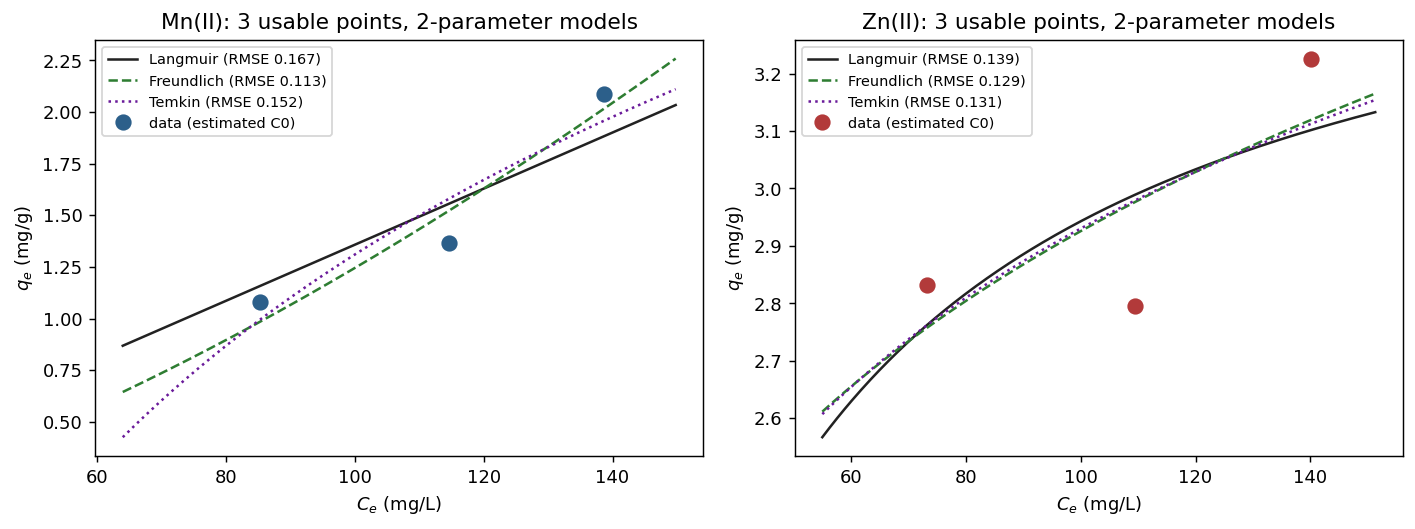

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
styles = {"Langmuir": ("-", "#222222"), "Freundlich": ("--", "#2e7d32"),
          "Temkin": (":", "#6a1b9a")}

for ax, data, res, metal, colour in [
        (axes[0], mn, res_mn, "Mn(II)", "#2c5f8a"),
        (axes[1], zn, res_zn, "Zn(II)", "#b23a3a")]:
    grid = np.linspace(data.Ce.min() * 0.75, data.Ce.max() * 1.08, 300)
    for name, r in res.items():
        if not r["converged"]:
            continue
        func = {"Langmuir": langmuir, "Freundlich": freundlich,
                "Temkin": temkin}[name]
        ls, c = styles[name]
        ax.plot(grid, func(grid, *r["params"]), ls, color=c, lw=1.4,
                label=f"{name} (RMSE {r['rmse']:.3f})")
    ax.plot(data.Ce, data.qe, "o", color=colour, ms=8, label="data (estimated C0)")
    ax.set_xlabel("$C_e$ (mg/L)")
    ax.set_ylabel("$q_e$ (mg/g)")
    ax.set_title(f"{metal}: 3 usable points, 2-parameter models")
    ax.legend(fontsize=8)

fig.tight_layout()

## Why no information criterion is reported here

AICc requires `n - k - 1 > 0`. With three observations and two parameters that
denominator is zero, so AICc is undefined. The helper returns `NaN` rather than
a number that would look like evidence.

In [7]:
from adsorption import aicc
print("AICc for a 2-parameter model on 3 points:",
      aicc(sse=0.05, n=3, k=2))
print("(undefined: n - k - 1 = 0)")
print()
print("So the isotherm models can only be ranked descriptively, by RMSE,")
print("and the ranking carries far less weight than the kinetics ranking")
print("in notebook 02, where n = 5 makes AICc well defined.")

AICc for a 2-parameter model on 3 points: nan
(undefined: n - k - 1 = 0)

So the isotherm models can only be ranked descriptively, by RMSE,
and the ranking carries far less weight than the kinetics ranking
in notebook 02, where n = 5 makes AICc well defined.


## The linearised forms, and why they are not used

The linearised Langmuir plot puts `Ce` on both axes as `Ce/qe` against `Ce`.
Any dataset at all will look linear in those coordinates.

In [8]:
lin = linregress(zn["Ce"], zn["Ce"] / zn["qe"])
print(f"Zn(II) linearised Langmuir (Ce/qe vs Ce): R2 = {lin.rvalue**2:.2f}")
print(f"Zn(II) non-linear Langmuir:               R2 = {res_zn['Langmuir']['r2']:.2f}")
print()
print("The same three points, the same model. The linearised R2 of 0.94 is an")
print("artefact of Ce appearing on both axes; the non-linear fit on the")
print("untransformed data gives 0.49. Reporting the first would overstate the")
print("evidence by a wide margin, so the non-linear results are used.")

Zn(II) linearised Langmuir (Ce/qe vs Ce): R2 = 0.94
Zn(II) non-linear Langmuir:               R2 = 0.49

The same three points, the same model. The linearised R2 of 0.94 is an
artefact of Ce appearing on both axes; the non-linear fit on the
untransformed data gives 0.49. Reporting the first would overstate the
evidence by a wide margin, so the non-linear results are used.


## Conclusions

- **Mn(II)**: best described by Freundlich with `1/n = 1.47`. The exponent above
  1 marks unfavourable uptake over this range, and the Langmuir fit degenerates
  to a straight line, so no monolayer capacity exists for this system. The
  honest reading is that the sites were nowhere near saturated between 85 and
  139 mg/L.
- **Zn(II)**: uptake changes little between 73 and 140 mg/L and approaches a
  limiting value near 3.6 mg/g. All three models fit the three points within
  0.01 mg/g of each other, so **no model can be preferred**, and no mechanism
  can be read off the model choice.
- The parameters depend on the dilution convention from notebook 00. The
  exponent `1/n` and the ranking of the models do not.

The usual next sentence in an adsorption paper is "the Langmuir model fitted
best, indicating monolayer chemisorption". Neither half of that sentence is
supported here, and the analysis above is what shows it.